In [25]:
import os
import sys
import pandas as pd 
import numpy as np
import glob
import time
#import gget
import scipy
from scipy.sparse import csr_matrix
import anndata as an
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import ListedColormap
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

source_path = os.path.abspath("../utilities/")
sys.path.append(source_path)
import matrix as matrix
source_path = os.path.abspath("../utilities/calculations/")
sys.path.append(source_path)
import centrality as central

In [26]:
CN     = pd.read_csv("/scratch/indikar_root/indikar1/jduhamel/pore_c/centrality/max/core_nodes.csv")
CE     = pd.read_csv("/scratch/indikar_root/indikar1/jduhamel/pore_c/centrality/max/core_edges.csv")
H_core = sp.load_npz("/scratch/indikar_root/indikar1/jduhamel/pore_c/centrality/max/H_core.npz")  # rows = CN, cols = CE

print(f"CN: {len(CN)} core nodes")
print(f"CE: {len(CE)} core edges")
print(f"H_core: {H_core.shape}")
print(f"\nCN columns:  {CN.columns.tolist()}")
print(f"CE columns:  {CE.columns.tolist()}")

CN: 232 core nodes
CE: 32138 core edges
H_core: (232, 32138)

CN columns:  ['bin_name', 'chrom', 'bin_start', 'bin_end', 'global_hge_max_unweighted', 'is_core']
CE columns:  ['read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes']


In [27]:
%%time 
# 1MB resolution
resolution = 1000000

fpath = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/population_mESC_{resolution}_features.h5ad"

adata = sc.read_h5ad(fpath)

sc.logging.print_memory_usage()

adata

Memory usage: current 6.58 GB, difference +3.67 GB
CPU times: user 12.3 s, sys: 2.61 s, total: 14.9 s
Wall time: 16.6 s


AnnData object with n_obs × n_vars = 2579 × 2756467
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes'
    uns: 'base_resolution', 'chrom_sizes', 'gdf', 'gene_map', 'intervals'
    layers: 'H'

In [28]:
def find_outliers_iqr(df_column):
  """
  Identifies outliers in a pandas DataFrame column using the IQR method.

  Args:
    df_column: A pandas Series representing the column to analyze.

  Returns:
    A boolean mask with True for outliers and False otherwise.
  """
  Q1 = df_column.quantile(0.15)
  Q3 = df_column.quantile(0.85)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  return (df_column < lower_bound) | (df_column > upper_bound)

adata.obs['degree_outlier'] = find_outliers_iqr(adata.obs['degree'])

adata.obs[adata.obs['degree_outlier']][['chrom_bin', 'degree', 'degree_outlier']].head()

,chrom_bin,degree,degree_outlier
bin_name,,,
chr8:21,21,12931,True
chrX:139,139,1609,True
chrX:122,122,1726,True
chrX:123,123,610,True
chr8:20,20,15415,True


In [29]:
# remove outliers
remove_bins = adata.obs[adata.obs['degree_outlier']].index.to_list()
print(f"Removing {len(remove_bins)} outlier loci: ")
print(remove_bins)

adata = adata[~adata.obs_names.isin(remove_bins), :].copy()
#bdata = bdata[~bdata.obs_names.isin(remove_bins), :].copy()

print('done!')

Removing 148 outlier loci: 
['chr8:21', 'chrX:139', 'chrX:122', 'chrX:123', 'chr8:20', 'chrX:124', 'chr1:85', 'chrX:110', 'chrX:14', 'chrX:63', 'chrX:169', 'chr14:18', 'chrX:9', 'chrX:154', 'chr9:124', 'chrX:15', 'chrX:82', 'chr9:3', 'chrX:6', 'chrX:61', 'chrX:88', 'chrX:109', 'chrX:29', 'chrX:27', 'chrX:137', 'chr14:19', 'chrX:84', 'chrX:120', 'chrX:97', 'chrX:24', 'chrX:118', 'chr8:19', 'chrX:156', 'chr1:24', 'chrX:108', 'chrX:135', 'chrX:68', 'chrX:42', 'chrX:111', 'chr14:15', 'chrX:130', 'chr14:16', 'chrX:80', 'chrX:64', 'chrX:134', 'chrX:127', 'chrX:155', 'chr8:70', 'chrX:18', 'chrX:141', 'chrX:45', 'chrX:121', 'chr4:112', 'chr11:3', 'chr12:3', 'chrX:167', 'chrX:95', 'chrX:65', 'chr14:3', 'chrX:77', 'chr2:177', 'chrX:44', 'chrX:60', 'chrX:86', 'chrX:46', 'chr2:98', 'chrX:19', 'chrX:23', 'chrX:79', 'chrX:119', 'chr14:17', 'chrX:107', 'chrX:89', 'chr4:146', 'chr4:147', 'chrX:132', 'chrX:113', 'chrX:94', 'chrX:157', 'chrX:93', 'chr7:22', 'chr7:21', 'chrX:128', 'chr9:35', 'chrX:96', '

In [30]:
fpath = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/pop_mESC_1000000_hge_linear.csv"

df = pd.read_csv(fpath)
print(f"{df.shape=}")
print(df.columns)

df.shape=(2335, 5)
Index(['bin_name', 'chrom', 'bin_start', 'bin_end',
       'global_hge_linear_unweighted'],
      dtype='object')


In [31]:
columns_to_drop = ["chrom", "bin_start", "bin_end"]
df = df.drop(columns=columns_to_drop)
print(f"{df.shape=}")
df.head()

df.shape=(2335, 2)


,bin_name,global_hge_linear_unweighted
0,chr9:121,0.000455
1,chr19:26,0.000413
2,chr4:127,0.000476
3,chr10:57,0.000380
4,chr12:8,0.000444


In [32]:
adata.obs = pd.merge(
    adata.obs, df.set_index('bin_name'),
    how='left',
    left_index=True,
    right_index=True,
)

adata.obs.head()

,bin_index,bin_start,bin_end,bin,chrom,chrom_bin,degree,genes,n_genes,ATACSeq_1,...,H3K27me3,RNA_1,RNA_2,RNA_3,RNA_4,RNA_5,RNA_6,PolII,degree_outlier,global_hge_linear_unweighted
bin_name,,,,,,,,,,,,,,,,,,,,,
chr9:121,0,121000000,122000000,1394,9,121,3532,Gm47092;Higd1a;Gm47108;Gask1a;Lyzl4os;Gm47112;...,41,0.826484,...,0.866066,0.295370,0.387013,0.162437,0.225783,0.573875,0.122417,1.016765,False,0.000455
chr19:26,1,26000000,27000000,2436,19,26,3346,Gm50378;Smarca2;Gm50376;Gm48775;Gm815;1700048O...,11,0.497386,...,0.839273,0.133999,0.148066,0.132291,0.094680,0.141617,0.084908,0.417178,False,0.000413
chr4:127,2,127000000,128000000,665,4,127,3768,Gjb3;Gm22221;Gm12943;Zmym6;Tmem35b;Gjb5;Gm1294...,16,0.754788,...,0.839461,0.521087,0.998980,0.293742,0.247401,0.906364,0.256514,0.750054,False,0.000476
chr10:57,4,57000000,58000000,1455,10,57,3285,Serinc1;Smpdl3a;Rpl48-ps1;Gm19256;Gm48055;Fabp...,14,0.472903,...,0.600799,0.238078,0.560188,0.233549,0.215554,0.490113,0.182086,0.176728,False,0.000380
chr12:8,5,8000000,9000000,1659,12,8,3557,Gm56512;Ldah;5033421B08Rik;Rhob;Gm33037;Laptm4...,25,0.690311,...,0.833768,0.229539,0.501868,0.283553,0.190379,0.617768,0.222526,0.741199,False,0.000444


In [33]:
adata.obs["global_hge_linear_unweighted"].notna()

bin_name
chr9:121     True
chr19:26     True
chr4:127     True
chr10:57     True
chr12:8      True
            ...  
chr4:42     False
chr9:112     True
chr16:7      True
chr1:159     True
chr9:116     True
Name: global_hge_linear_unweighted, Length: 2431, dtype: bool

In [34]:
# remove_bins = adata.obs[adata.obs["global_hge_logexp_unweighted"].notna()].index.to_list()
# adata = adata[~adata.obs_names.isin(remove_bins), :].copy()

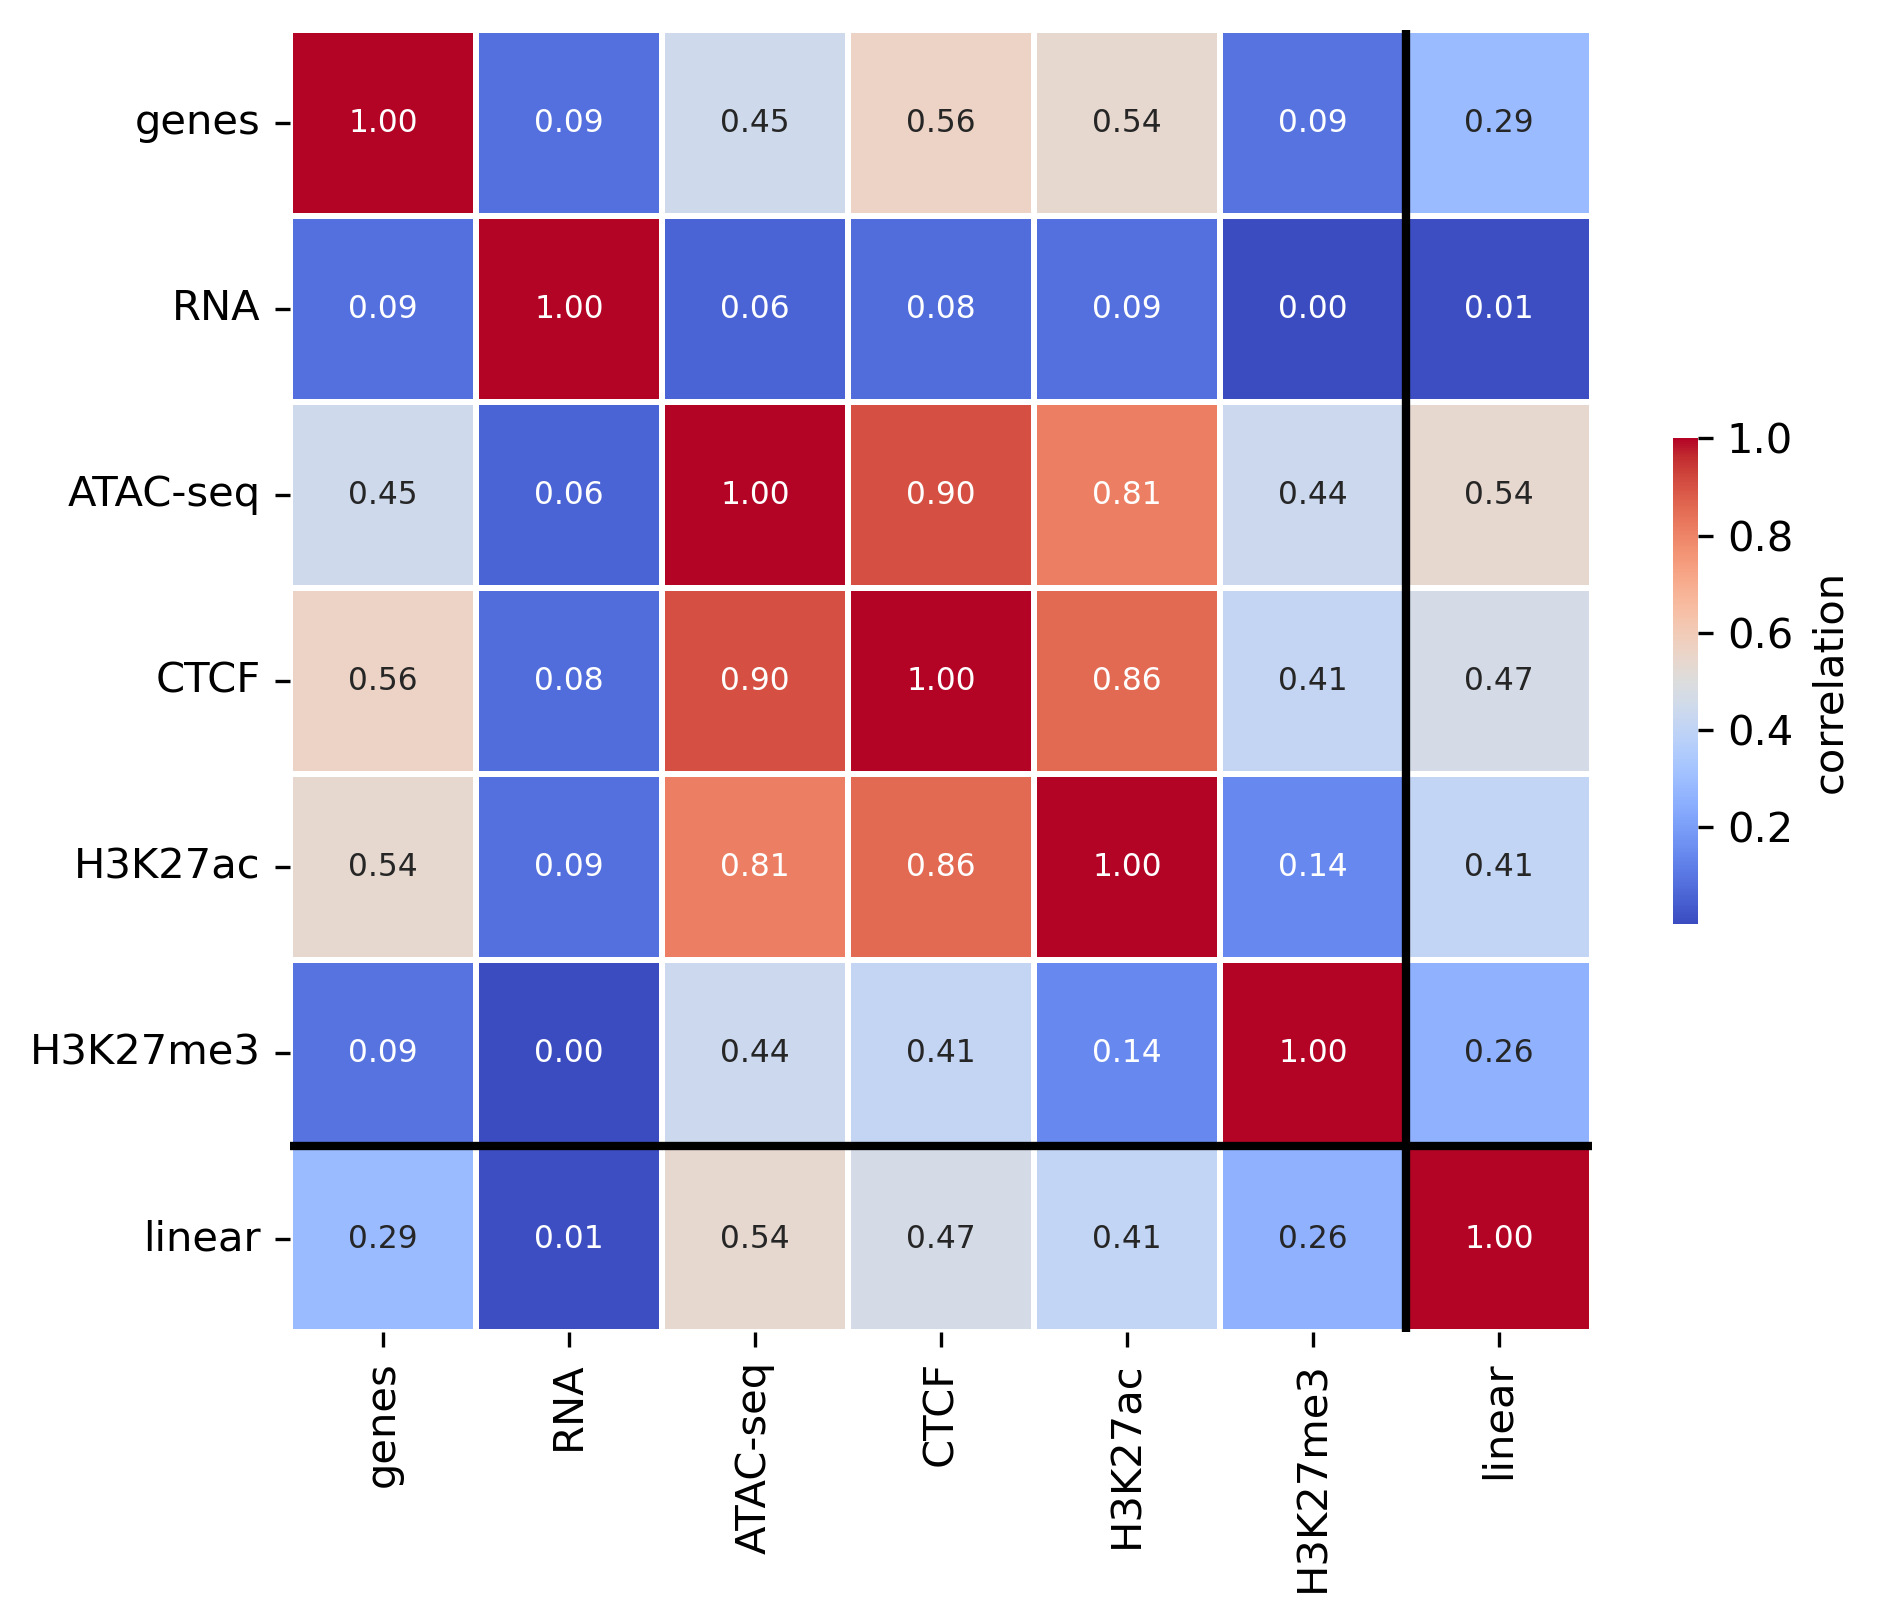

In [45]:
pdf = adata.obs.copy()

column_labels = {
    'n_genes': "genes",
    'RNA_5': "RNA",
    'ATACSeq_3': "ATAC-seq",
    'CTCF': "CTCF",
    'H3K27ac': "H3K27ac",
    'H3K27me3': "H3K27me3",
    'global_hge_linear_unweighted' : "linear",
}

corr = pdf[list(column_labels.keys())].corr()
corr.index = list(column_labels.values())
corr.columns = list(column_labels.values())

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7, 7

sns.heatmap(
    corr, 
    square=True,
    linewidths=1,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",  
    annot_kws={"size": 7.5},
    cbar_kws={'shrink': 0.3, 'label' : 'correlation'}
)

# Get the positions of the lines
# These positions are based on the order of your `column_labels`
lines = [6, 9,]

# Add vertical lines
for line in lines:
    plt.axvline(line, color='black', lw=2)
    plt.axhline(line, color='black', lw=2)


plt.savefig("correlation_linear.pdf", bbox_inches="tight")
plt.show()

In [46]:
adata

AnnData object with n_obs × n_vars = 2431 × 2756467
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII', 'degree_outlier', 'global_hge_linear_unweighted'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes'
    uns: 'base_resolution', 'chrom_sizes', 'gdf', 'gene_map', 'intervals'
    layers: 'H'

In [47]:
CN.shape

(232, 6)

In [48]:
cdata = adata.copy()

In [49]:
cdata

AnnData object with n_obs × n_vars = 2431 × 2756467
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII', 'degree_outlier', 'global_hge_linear_unweighted'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes'
    uns: 'base_resolution', 'chrom_sizes', 'gdf', 'gene_map', 'intervals'
    layers: 'H'

In [50]:
keep_bins = CN['bin_name'].to_list()
keep_bins[:6]

['chr3:34', 'chr6:93', 'chr3:94', 'chr3:32', 'chr18:3', 'chr12:113']

In [51]:
cdata = cdata[cdata.obs_names.isin(keep_bins), :].copy()

In [52]:
cdata.obs['global_hge_linear_unweighted']

bin_name
chr3:34     0.000559
chr6:93     0.000585
chr3:94     0.000555
chr3:32     0.000547
chr18:3     0.000533
              ...   
chr12:23    0.000604
chr7:83     0.000489
chr2:5      0.000496
chr5:26     0.000562
chr8:62     0.000534
Name: global_hge_linear_unweighted, Length: 232, dtype: float64

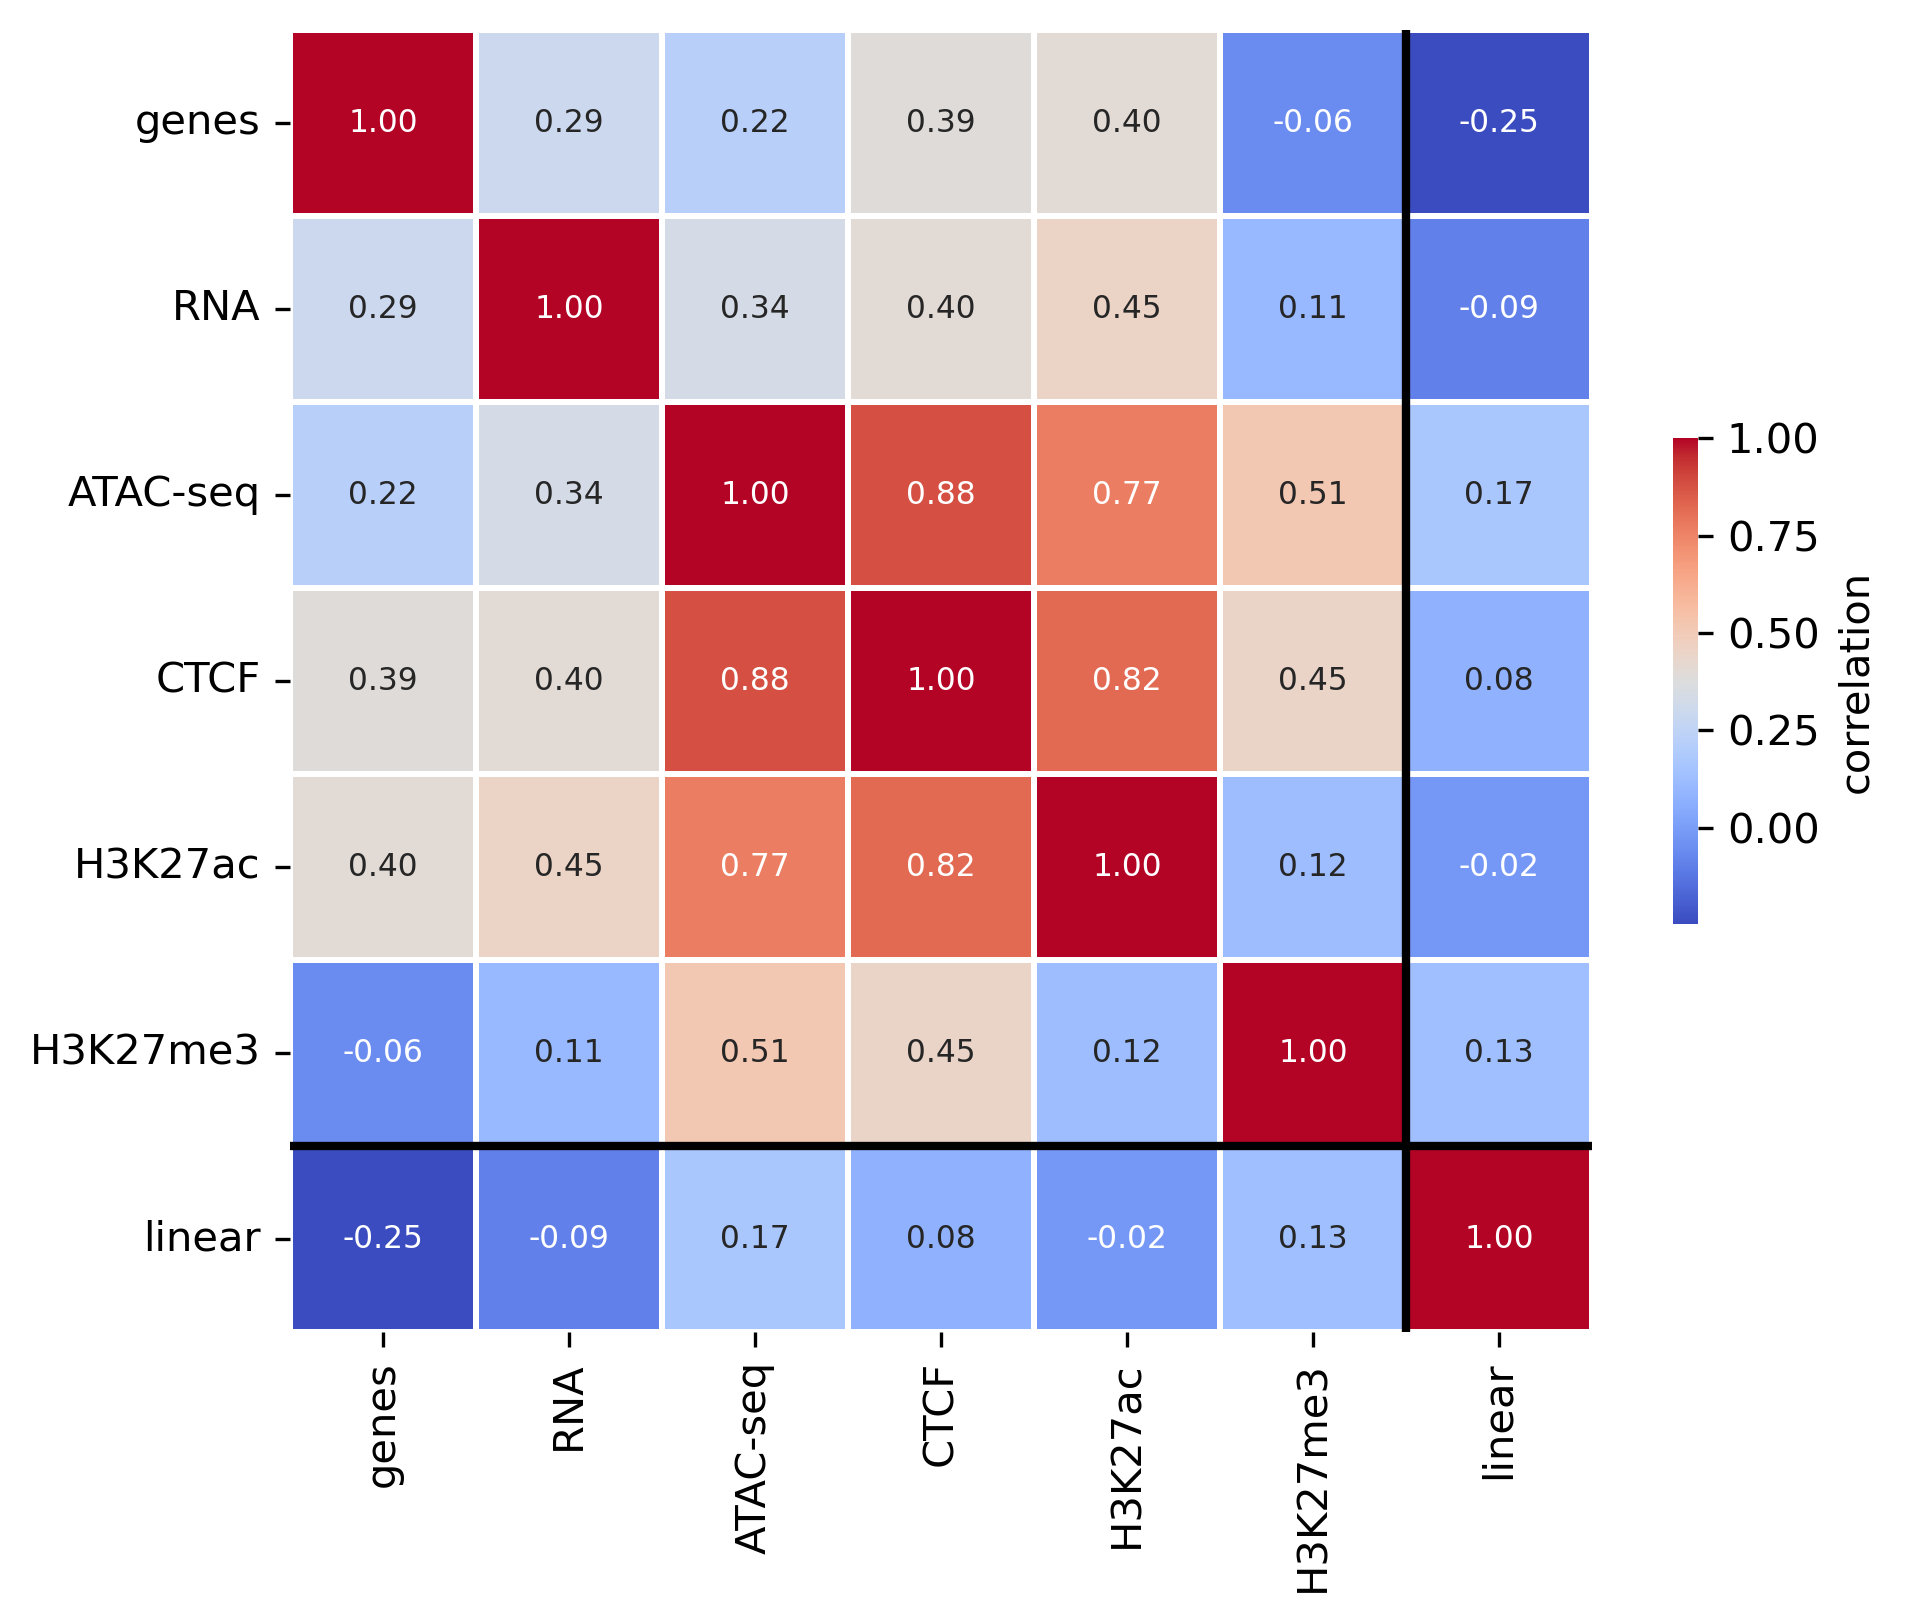

In [53]:
cdf = cdata.obs.copy()

column_labels = {
    'n_genes': "genes",
    'RNA_5': "RNA",
    'ATACSeq_3': "ATAC-seq",
    'CTCF': "CTCF",
    'H3K27ac': "H3K27ac",
    'H3K27me3': "H3K27me3",
    'global_hge_linear_unweighted' : "linear",
}

corr = cdf[list(column_labels.keys())].corr()
corr.index = list(column_labels.values())
corr.columns = list(column_labels.values())

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7, 7

sns.heatmap(
    corr, 
    square=True,
    linewidths=1,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",  
    annot_kws={"size": 7.5},
    cbar_kws={'shrink': 0.3, 'label' : 'correlation'}
)

# Get the positions of the lines
# These positions are based on the order of your `column_labels`
lines = [6, 9,]

# Add vertical lines
for line in lines:
    plt.axvline(line, color='black', lw=2)
    plt.axhline(line, color='black', lw=2)

plt.savefig("correlation_linear_dropped_bins.pdf", bbox_inches="tight")

plt.show()

In [54]:
target_col = 'global_hge_linear_unweighted'

# Calculate min and max
col_min = cdata.obs[target_col].min()
col_max = cdata.obs[target_col].max()

# Apply the transformation
cdata.obs[f'{target_col}_norm'] = (cdata.obs[target_col] - col_min) / (col_max - col_min)

In [55]:
cdata

AnnData object with n_obs × n_vars = 232 × 2756467
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII', 'degree_outlier', 'global_hge_linear_unweighted', 'global_hge_linear_unweighted_norm'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes'
    uns: 'base_resolution', 'chrom_sizes', 'gdf', 'gene_map', 'intervals'
    layers: 'H'

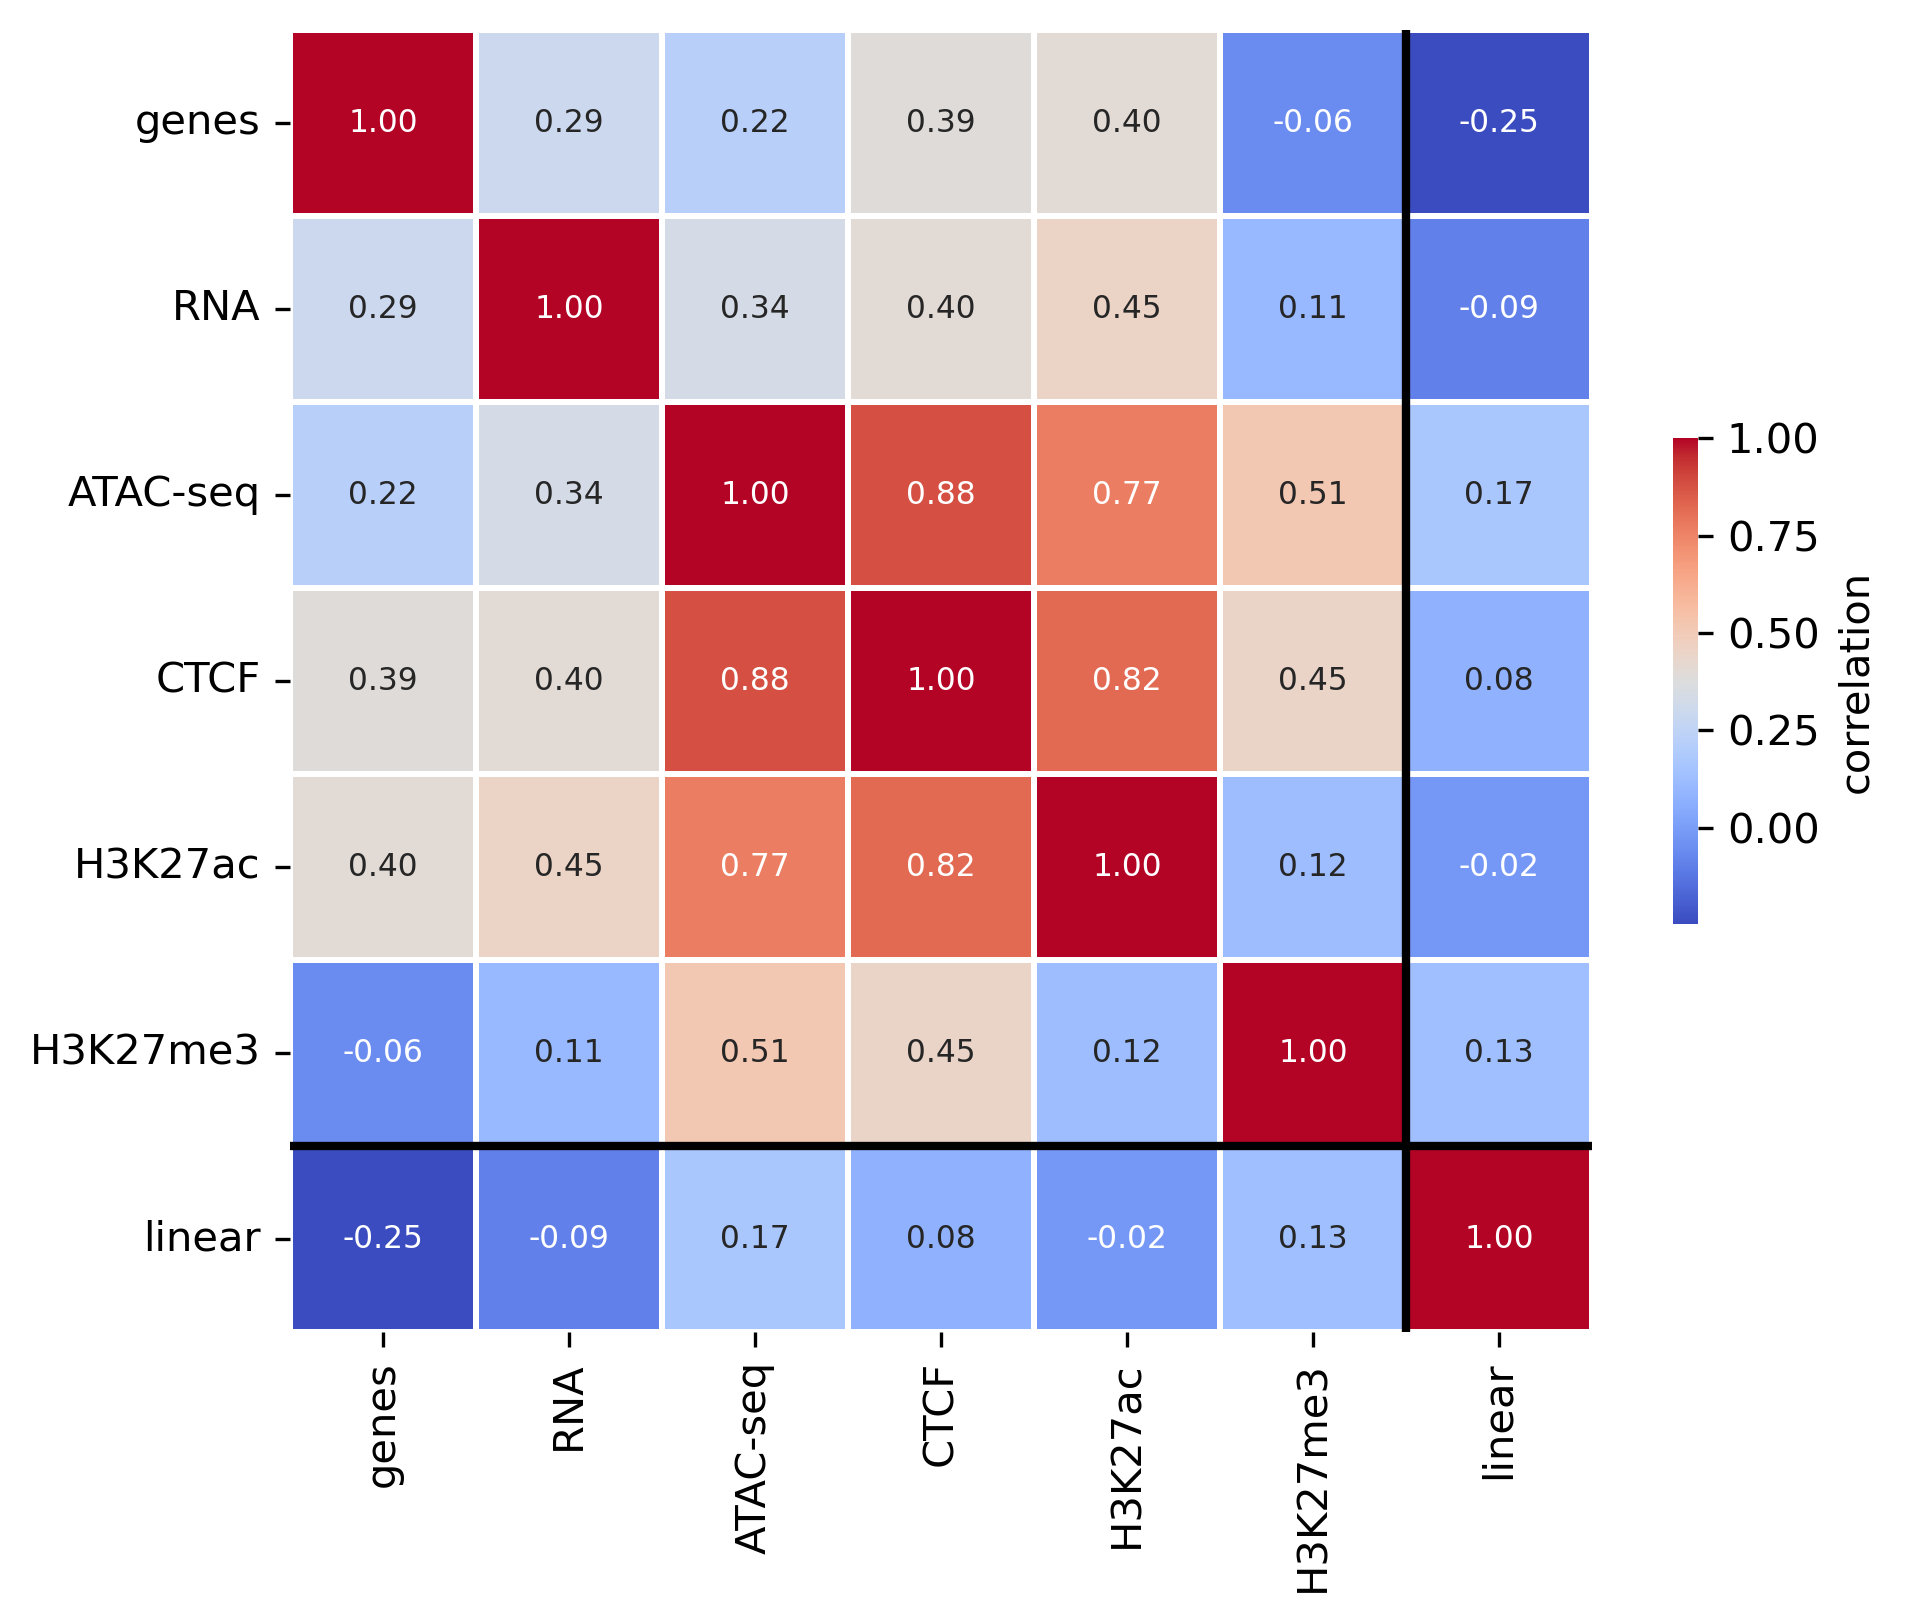

In [57]:
cdf = cdata.obs.copy()

column_labels = {
    'n_genes': "genes",
    'RNA_5': "RNA",
    'ATACSeq_3': "ATAC-seq",
    'CTCF': "CTCF",
    'H3K27ac': "H3K27ac",
    'H3K27me3': "H3K27me3",
    'global_hge_linear_unweighted_norm' : "linear",
}

corr = cdf[list(column_labels.keys())].corr()
corr.index = list(column_labels.values())
corr.columns = list(column_labels.values())

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7, 7

sns.heatmap(
    corr, 
    square=True,
    linewidths=1,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",  
    annot_kws={"size": 7.5},
    cbar_kws={'shrink': 0.3, 'label' : 'correlation'}
)

# Get the positions of the lines
# These positions are based on the order of your `column_labels`
lines = [6, 9,]

# Add vertical lines
for line in lines:
    plt.axvline(line, color='black', lw=2)
    plt.axhline(line, color='black', lw=2)

plt.savefig("correlation_linear_normalized.pdf", bbox_inches="tight")

plt.show()